# 0) Import data

In [1]:
import pandas as pd
data = pd.read_csv("exam_2020_01_07_data.csv")
data.head()

,C00,C01,C02,C03,C04,Class
0,1.855416,0.466367,-0.176765,1.546514,0.149219,c
1,-0.107873,-0.136792,1.551591,-0.813810,1.357674,a
2,2.712560,-0.495846,1.397077,1.483562,1.656526,b
3,-2.166084,-0.582271,0.353011,-1.864210,-2.267033,b
4,2.848831,-0.507369,1.661752,1.466627,1.938519,b


# 1) Pairplot of data

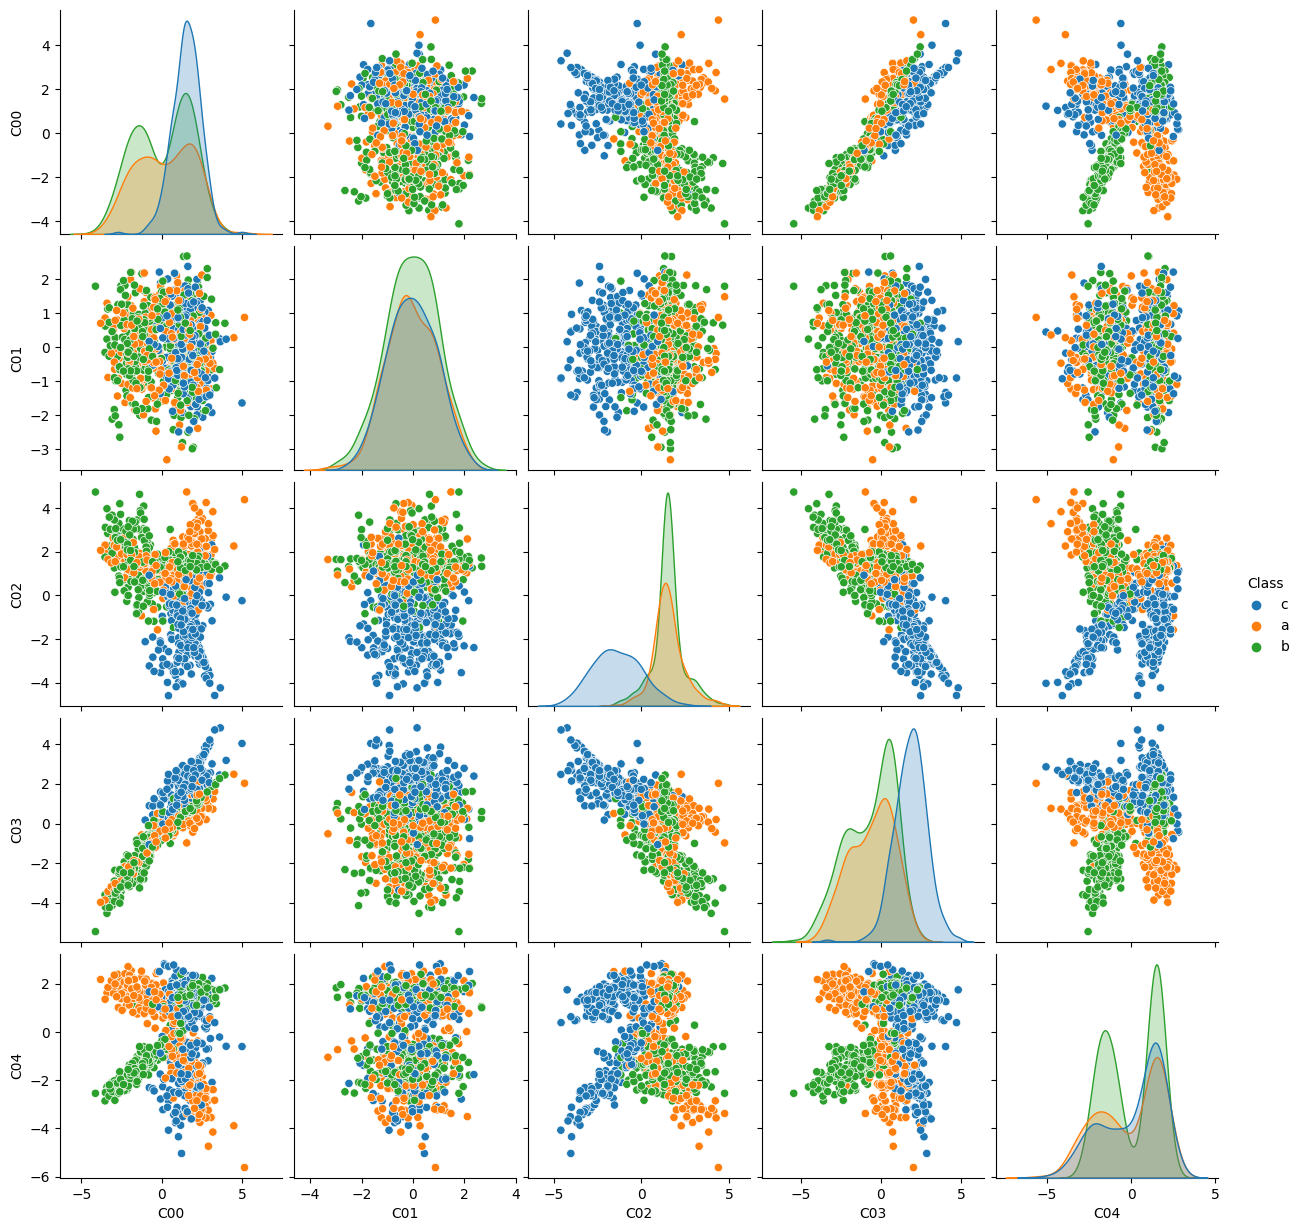

In [2]:
import seaborn as sns
import warnings
warnings.filterwarnings("ignore")

sns.pairplot(data=data, hue="Class");

The data is centered and there are not clear cluster based on attributes.

# 2) Classification model using a method of your choice with the schema "train-validation-test" exploring an appropriate range of parameter values.

In [25]:
# Constants
train_size = 0.75
random_state = 42

# Dataset extraction
target = data.columns[-1]
attributes = data.columns[:-1]
X = data[attributes]
y = data[target]

# Train-validation-test
from sklearn.model_selection import train_test_split
X_train_val, X_test, y_train_val, y_test = train_test_split(
    X, y, 
    train_size=train_size,
    random_state=random_state
)
X_train, X_val, y_train, y_val = train_test_split(
    X_train_val, y_train_val, 
    train_size=train_size,
    random_state=random_state
)
print(y_train.shape, y_val.shape, y_test.shape)

(562,) (188,) (250,)


In [20]:
# We have to define the max-depth of our Tree
from sklearn.tree import DecisionTreeClassifier
tree=DecisionTreeClassifier(random_state=random_state)
tree.fit(X_train, y_train)
max_depth=tree.get_depth()
print(f"The maximum depth is {max_depth}")

from sklearn.model_selection import ParameterGrid
parameters = ParameterGrid({
    "criterion" : ["gini", "entropy", "log_loss"],
    "max_depth" : [*range(1,max_depth+1)],
    "splitter" : ["best", "random"]
})

The maximum depth is 11


In [21]:
from sklearn.metrics import accuracy_score

best_accuracy = 0
best_params = None
for parameter in parameters:
    model=DecisionTreeClassifier(random_state=random_state, **parameter)
    model.fit(X_train, y_train)
    y_pred = model.predict(X_val)
    accuracy = accuracy_score(y_val, y_pred)
    
    if accuracy > best_accuracy:
        best_accuracy = accuracy
        best_params = parameter


# 3) Optimal parameters

In [28]:
best_dt = DecisionTreeClassifier(random_state=random_state, **best_params)
best_dt.fit(X_train, y_train)

y_pred = best_dt.predict(X_test)
print(f"Best model: {best_params}")
print(f"The accuracy is {accuracy_score(y_test, y_pred)*100}%")

Best model: {'criterion': 'gini', 'max_depth': 7, 'splitter': 'best'}
The accuracy is 90.0%


# 4) Scatterplot of test set

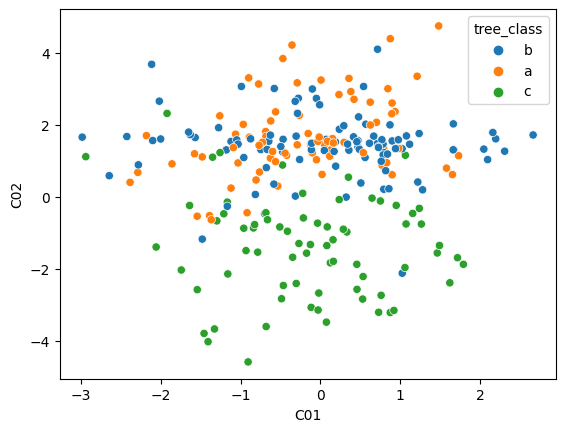

In [23]:
# Select the first 2 attributes
attr = attributes[1:3]

scatt_data = X_test.copy()
scatt_data["tree_class"] = y_pred

# Scatterplot
sns.scatterplot(
    data=scatt_data,
    x = attr[0],
    y = attr[1],
    hue="tree_class"
);

# 5) add good/bad prediction to scatterplot

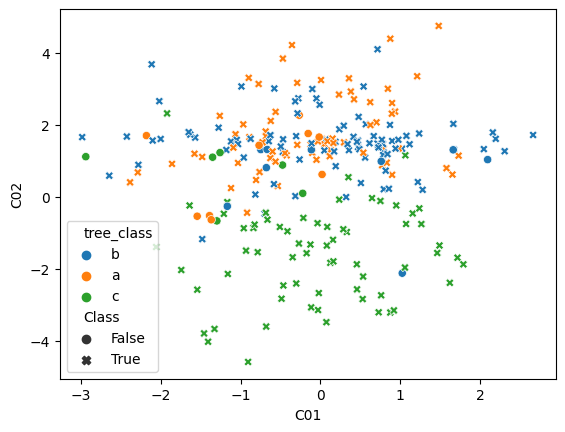

In [24]:
# Scatterplot
good_mask = (y_test==y_pred)
sns.scatterplot(
    data=scatt_data,
    x = attr[0],
    y = attr[1],
    hue="tree_class",
    style = good_mask
);